In [1]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
model_path = r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models"

# List of model files
model_files = [
    "best_lgbm_rr_pipeline.pkl",    # 8 features
    "best_RF1_rr_pipeline.pkl",     # 8 features
    "best_RF2_rr_pipeline.pkl",     # 8 features
    "LGBM_rr_pipeline.pkl",         # 12 features (baseline)
    "RF_rr_pipeline.pkl"            # 12 features (baseline)
]

# Load models
models = {}
for file in model_files:
    full_path = os.path.join(model_path, file)
    models[file.split('.')[0]] = joblib.load(full_path)

print("Models loaded:", list(models.keys()))

Models loaded: ['best_lgbm_rr_pipeline', 'best_RF1_rr_pipeline', 'best_RF2_rr_pipeline', 'LGBM_rr_pipeline', 'RF_rr_pipeline']


In [3]:
# Top 8 features for tuned models
top_8_features = ['dominant_freq', 'resp_power', 'rr_dominant_freq', 'total_power',
                  'ptp', 'rr_resp_power', 'rr_total_power', 'skew']

# All 12 features for baseline models
all_12_features = ['mean', 'std', 'skew', 'kurtosis', 'rms', 'ptp', 'dominant_freq', 
                   'resp_power', 'total_power', 'rr_dominant_freq', 'rr_resp_power', 'rr_total_power']

In [4]:
# Example: 5 samples for all 12-feature models
sample_12 = np.array([
    [0.001, 0.005, 0.2, -0.6, 0.005, 0.022, 16.2, 0.003, 0.003, 13.6, 0.0005, 0.0006],
    [0.002, 0.004, 0.1, -0.5, 0.004, 0.021, 16.5, 0.002, 0.002, 14.0, 0.0004, 0.0005],
    [0.0005, 0.006, 0.3, -0.4, 0.006, 0.023, 15.8, 0.004, 0.004, 13.2, 0.0006, 0.0007],
    [0.0015, 0.005, 0.25, -0.55, 0.005, 0.0225, 16.1, 0.0035, 0.0035, 13.5, 0.00055, 0.00065],
    [0.0012, 0.0045, 0.15, -0.45, 0.0045, 0.0215, 16.3, 0.0025, 0.0025, 13.8, 0.00045, 0.00055]
])

# Example: 5 samples for all 8-feature models
sample_8 = np.array([
    [16.2, 0.003, 0.0005, 13.6, 0.022, 0.0006, 0.0012, 0.23],
    [16.5, 0.002, 0.0004, 14.0, 0.021, 0.0005, 0.0010, 0.19],
    [15.8, 0.004, 0.0006, 13.2, 0.023, 0.0007, 0.0013, 0.25],
    [16.1, 0.0035, 0.00055, 13.5, 0.0225, 0.00065, 0.00125, 0.22],
    [16.3, 0.0025, 0.00045, 13.8, 0.0215, 0.00055, 0.00115, 0.20]
])

In [5]:
predictions = {}

for name, model in models.items():
    # Get expected input size
    expected_feats = model.named_steps['scaler'].mean_.shape[0]
    
    if expected_feats == 12:
        pred = model.predict(sample_12)
        predictions[name] = pred
        print(f"{name} (12 features) predictions:", pred)
    elif expected_feats == 8:
        pred = model.predict(sample_8)
        predictions[name] = pred
        print(f"{name} (8 features) predictions:", pred)
    else:
        raise ValueError(f"Unexpected number of features for model {name}")

best_lgbm_rr_pipeline (8 features) predictions: [15.23547024 15.46244048 15.26581151 15.23642262 15.36193254]
best_RF1_rr_pipeline (8 features) predictions: [15.23547024 15.46244048 15.26581151 15.23642262 15.36193254]
best_RF2_rr_pipeline (8 features) predictions: [15.10793095 15.32574286 15.16860714 15.12174048 15.21995238]


C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LGBM_rr_pipeline (12 features) predictions: [19.57981555 20.23879061 20.32903072 19.23398359 20.07887541]
RF_rr_pipeline (12 features) predictions: [20.95623588 20.20209403 19.43792449 19.42525762 20.63768544]


In [6]:
# Convert to DataFrame: rows = samples, columns = model names
pred_df = pd.DataFrame(predictions)
pred_df.index = [f"Sample {i+1}" for i in range(5)]
pred_df

,best_lgbm_rr_pipeline,best_RF1_rr_pipeline,best_RF2_rr_pipeline,LGBM_rr_pipeline,RF_rr_pipeline
Sample 1,15.235470,15.235470,15.107931,19.579816,20.956236
Sample 2,15.462440,15.462440,15.325743,20.238791,20.202094
Sample 3,15.265812,15.265812,15.168607,20.329031,19.437924
Sample 4,15.236423,15.236423,15.121740,19.233984,19.425258
Sample 5,15.361933,15.361933,15.219952,20.078875,20.637685


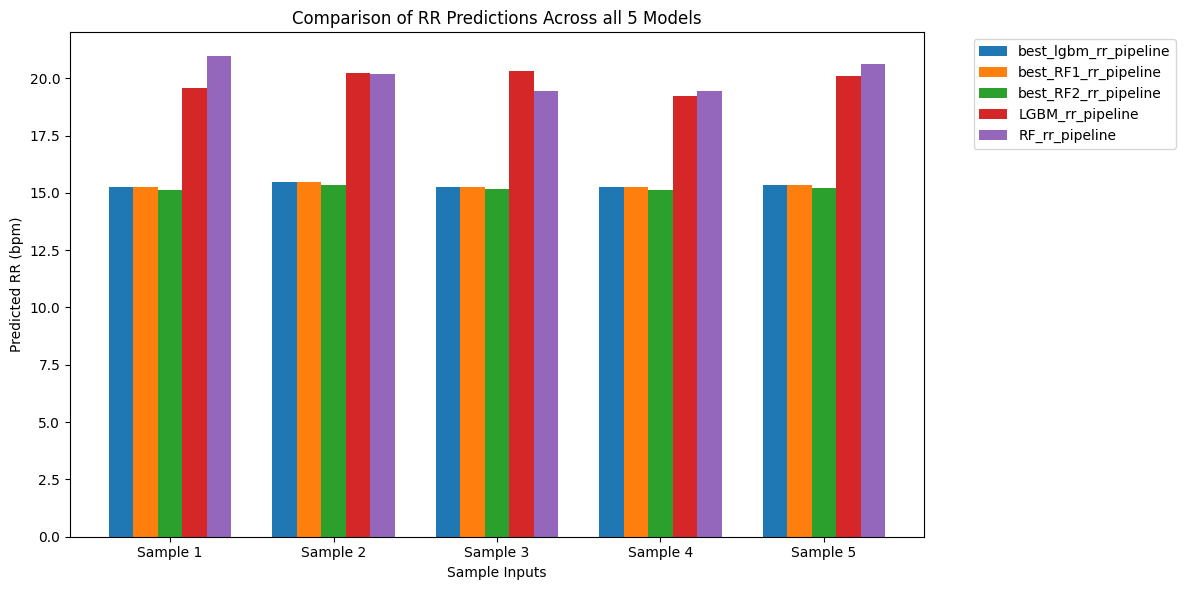

In [7]:
import matplotlib.pyplot as plt

# Set up figure
plt.figure(figsize=(12,6))

# Number of samples
n_samples = 5
# Number of models
n_models = len(pred_df.columns)
# X-axis positions
x = np.arange(n_samples)
# Width of each bar
width = 0.15

# Plot each model's predictions
for i, model_name in enumerate(pred_df.columns):
    plt.bar(x + i*width, pred_df[model_name], width=width, label=model_name)

# Labels and layout
plt.xlabel("Sample Inputs")
plt.ylabel("Predicted RR (bpm)")
plt.title("Comparison of RR Predictions Across all 5 Models")
plt.xticks(x + width*(n_models-1)/2, [f"Sample {i+1}" for i in range(n_samples)])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()